<h1> Entanglement based Quantum Key Distribution Network</h1>


In [1]:
from qiskit import QuantumRegister, ClassicalRegister,QuantumCircuit
import numpy as np
import random
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector,Operator
from qiskit.visualization import circuit_drawer, plot_histogram
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeFez
import re
from qiskit.primitives import Estimator

In [2]:
backend = AerSimulator()# uncomment this command line if needed to run with free noise
pm = generate_preset_pass_manager(optimization_level = 1,
                             backend = backend,
                             seed_transpiler = 24578)

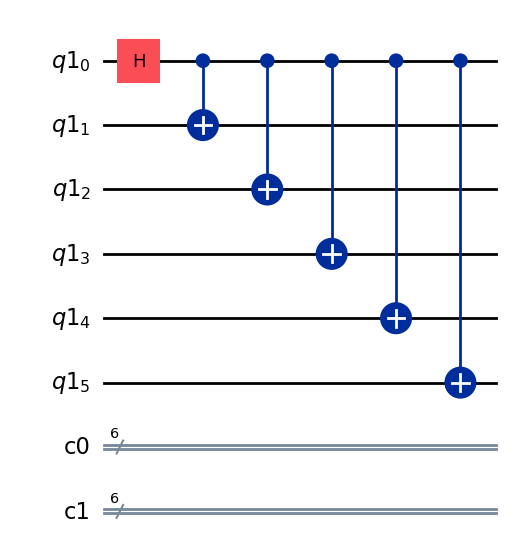

In [3]:
#|Psi> = (|000>+|111>)/sqrt(2)
nq = 6
N = 2000
basis_1 = ['X','V','Y','R']
basis_k = ['X','Y']
basis_choices = [[random.choice(basis_1) for _ in range(N)]]+[[random.choice(basis_k) 
                                                               for _ in range(N)] for _ in range(nq-1) ]
# basis_choices
QR = QuantumRegister(nq)
CR = ClassicalRegister(nq)
QR_e = QuantumRegister(nq)
CR_e = ClassicalRegister(nq)
def N_particles_state(nq,QR,CR,CR_e):
    qc = QuantumCircuit(QR, CR, CR_e )
    qc.h(QR[0])
    for k in range(1,nq):
        qc.cx(QR[0],QR[k])
    return qc

Psi = N_particles_state(nq,QR,CR,CR_e)
Psi.draw('mpl')



<h3> d) Measurement bases encoded with quantum gates </h3>


Observables in the xy-plane: $O(\theta) = cos(\theta) \sigma_x + sin(\theta) \sigma_y$


Specific angles giving the maximal Svetlichny violation
\begin{equation}
\begin{aligned}
&A:\quad \theta_A = {\frac{3\pi}{4},0,\frac{\pi}{4},\frac{\pi}{2}} \quad\Rightarrow\quad A = V={\frac{\sigma_x-\sigma_y}{\sqrt{2}},R=\frac{\sigma_x+\sigma_y}{\sqrt{2}},X,Y }\\[6pt]
&B:\quad \theta_B = {0, \frac{\pi}{2}} \quad\Rightarrow\quad B = {\sigma_x,\sigma_y}\\[6pt]
&B:\quad \theta_C = {0, \frac{\pi}{2}} \quad\Rightarrow\quad C = {\sigma_x,\sigma_y}
\end{aligned}
\end{equation}





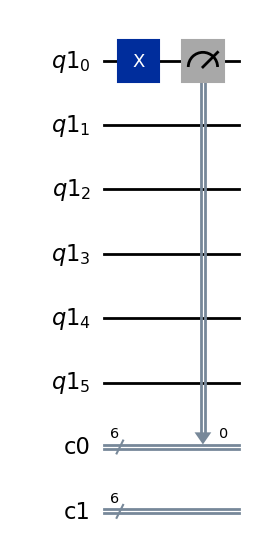

In [4]:

def legitimate_users_mes_circs(nq,N,QR,CR,CR_e):
    #  Legitimate_parties_1's qubit onto the X basis
    Legitimate_parties_1_X = QuantumCircuit(QR,CR,CR_e)
    Legitimate_parties_1_X.x(QR[0])
    Legitimate_parties_1_X.measure(QR[0],CR[0])
    
    # Legitimate_parties_1's qubit onto the Y basis 
    Legitimate_parties_1_Y = QuantumCircuit(QR,CR,CR_e)
    # Legitimate_parties_1_Y.sdg(QR_abc[0])
    Legitimate_parties_1_Y.y(QR[0])
    Legitimate_parties_1_Y.measure(QR[0],CR[0])
    
    # Legitimate_parties_1's qubit onto the R basis R = Rz(-pi/4)H = (X+Y)/sqrt(2)
    Legitimate_parties_1_R = QuantumCircuit(QR,CR,CR_e)
    Legitimate_parties_1_R.rz(-np.pi/4,QR[0])
    Legitimate_parties_1_R.h(QR[0])
    Legitimate_parties_1_R.measure(QR[0],CR[0])

    # Legitimate_parties_1's qubit onto the V basis V = Rz(pi/4)H = (X-Y)/sqrt(2)
    Legitimate_parties_1_V = QuantumCircuit(QR,CR,CR_e)
    Legitimate_parties_1_V.rz(np.pi/4,QR[0])
    Legitimate_parties_1_V.h(QR[0])
    Legitimate_parties_1_V.measure(QR[0],CR[0])
    Legitimate_parties_1_meas_circs = [Legitimate_parties_1_X, Legitimate_parties_1_Y, 
                                       Legitimate_parties_1_V, Legitimate_parties_1_R]
    
    Legitimate_parties_k_meas_circs = []
    Legitimate_parties_k_meas_circs2 = []
    for k in range(1,nq):
        # Legitimate_parties_k_basis = {'X','Y'}
        # Legitimate_parties_k's qubit onto the Y basis
        
        Legitimate_parties_k_Y = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_Y.sdg(QR[k])
        Legitimate_parties_k_Y.h(QR[k])
        Legitimate_parties_k_Y.measure(QR[k],CR[k])
        
        Legitimate_parties_k_Y2 = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_Y2.y(QR[k])
        Legitimate_parties_k_Y2.measure(QR[k],CR[k])
    
        # Legitimate_parties_k's qubit onto the X basis
        Legitimate_parties_k_X = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_X.h(QR[k])
        Legitimate_parties_k_X.measure(QR[k],CR[k])
        
        Legitimate_parties_k_X2 = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_X2.x(QR[k])
        Legitimate_parties_k_X2.measure(QR[k],CR[k])
        
        Legitimate_parties_k_meas_circs.append([Legitimate_parties_k_X,Legitimate_parties_k_Y])
        Legitimate_parties_k_meas_circs2.append([Legitimate_parties_k_X2,Legitimate_parties_k_Y2])
    
    Legitimate_parties_meas_circs = [Legitimate_parties_1_meas_circs]+Legitimate_parties_k_meas_circs
    Legitimate_parties_meas_circs2 = [Legitimate_parties_1_meas_circs]+Legitimate_parties_k_meas_circs2
    return Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2
    
Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2 = legitimate_users_mes_circs(nq,N,QR,CR,CR_e)

Legitimate_parties_meas_circs2[0][0].draw('mpl')

In [5]:
def circs(nq,N,basis_choices,Psi,Legitimate_parties_meas_circs,
          Legitimate_parties_meas_circs2):
    circuits = [] 
    circuits2 = [] 
    #basis_choices[[],[]...[]]
    
    for k in range(N):
        if basis_choices[0][k] == 'X':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][0])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][0])
            circuits.append(circ)
            circuits2.append(circ2)
        elif basis_choices[0][k] == 'Y':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][1])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][1])
            circuits.append(circ)
            circuits2.append(circ2)
        elif basis_choices[0][k] == 'V':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][2])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][2])
            circuits.append(circ)
            circuits2.append(circ2)
    
        elif basis_choices[0][k] == 'R':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][3])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][3])
            circuits.append(circ)
            circuits2.append(circ2)
    
    for j in range(1,nq):
        for k in range(N):  
            circs = circuits[k]
            circs2 = circuits2[k]
            if basis_choices[j][k] == 'X':
                circ = circs.compose(Legitimate_parties_meas_circs[j][0])
                circ2 = circs2.compose(Legitimate_parties_meas_circs2[j][0])
                circuits[k] = circ
                circuits2[k] = circ2
            elif basis_choices[j][k] == 'Y':
                circ = circs.compose(Legitimate_parties_meas_circs[j][1])
                circ2 = circs2.compose(Legitimate_parties_meas_circs2[j][1])
                circuits[k] = circ
                circuits2[k] = circ2
    return circuits,circuits2

circuits, circuits2 = circs(nq,N,basis_choices,Psi,Legitimate_parties_meas_circs,
                 Legitimate_parties_meas_circs2)
    

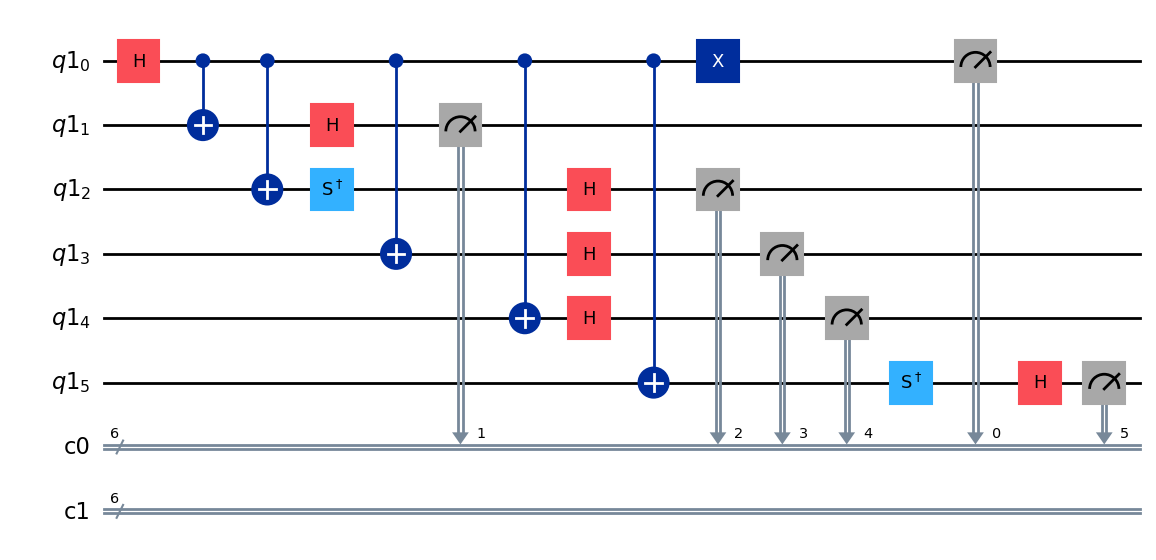

In [6]:
circuits[-1].draw('mpl')

In [7]:
print(len(circuits))
print(len(circuits2))

2000
2000


In [8]:
def simulation(N,backend,circuits,circuits2):
    pmv = generate_preset_pass_manager(
        optimization_level = 1, 
        backend = backend, 
        seed_transpiler = 1234,
        )
    
    Result = []
    Result2 = []
    for k in range(N):
        qc = circuits[k]
        qc2 = circuits2[k]
        qct = pmv.run(qc)
        qct2 = pmv.run(qc2)
        result = backend.run(qct, shots = 1).result() 
        result2 = backend.run(qct2, shots = 1).result() 
        res = result.get_counts()
        res2 = result2.get_counts()
        Result.append(res)
        Result2.append(res2)
    return Result,Result2
Result,Result2 = simulation(N,backend,circuits,circuits2)
print(Result)
print(Result2)

[{'000000 011110': 1}, {'000000 000001': 1}, {'000000 110111': 1}, {'000000 000110': 1}, {'000000 010010': 1}, {'000000 010110': 1}, {'000000 010111': 1}, {'000000 011100': 1}, {'000000 110011': 1}, {'000000 110000': 1}, {'000000 101111': 1}, {'000000 000101': 1}, {'000000 101010': 1}, {'000000 110000': 1}, {'000000 110011': 1}, {'000000 001010': 1}, {'000000 001111': 1}, {'000000 101111': 1}, {'000000 100001': 1}, {'000000 111011': 1}, {'000000 001110': 1}, {'000000 000110': 1}, {'000000 010101': 1}, {'000000 111111': 1}, {'000000 000111': 1}, {'000000 011001': 1}, {'000000 110110': 1}, {'000000 100100': 1}, {'000000 110010': 1}, {'000000 100010': 1}, {'000000 110000': 1}, {'000000 001110': 1}, {'000000 101110': 1}, {'000000 110001': 1}, {'000000 100011': 1}, {'000000 110110': 1}, {'000000 001001': 1}, {'000000 101101': 1}, {'000000 011000': 1}, {'000000 100110': 1}, {'000000 000100': 1}, {'000000 110011': 1}, {'000000 000000': 1}, {'000000 010001': 1}, {'000000 101100': 1}, {'000000 

In [9]:
print(len(Result))
print(len(Result2))

2000
2000


In [10]:
def Legitimate_parties_secret_keys(nq,N,Result):
    keyss = np.array([[0]*N]*nq)
    for k in range(N):
        key = list(Result[k].keys())
        for j in range(nq):
            if key[0][nq+j+1] == '1':
                keyss[j,k] = '1'
            elif key[0][nq+j+1] == '0':
                keyss[j,k] = '0'

    Res = []
    L = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'X':
            l = ['X']
            for j in range(1,nq):
                l.append(basis_choices[j][k])
            L.append(l)
            k_list.append(k)
        elif basis_choices[0][k] == 'Y':
            l = ['Y']
            for j in range(1,nq):
                l.append(basis_choices[j][k])            
            L.append(l)
            k_list.append(k)
        
    Y_counter = []#This contains the number of Y basis in each set of bases in L
    for k in range(len(L)):
        compt = 0
        for j in range(len(L[0])):
            if L[k][j] == 'Y':
                compt += 1
        Y_counter.append(compt)

    Keys = [] #this contains the set of key bit of each user
    for k in range(nq):
        q = keyss[k]
        A = []
        for j in range(len(Y_counter)):
            if Y_counter[j]%2 == 0:# because when the is an odd number of Y basis selected the user
                                    # are most likely to get the same output results. 
                A.append(str(q[k_list[j]]))  
        Keys.append(A)
    generated_keys = []
    for k in range(len(Keys)):
        x = ''
        for j in Keys[k]:
            x += j
        generated_keys.append(x)
    
    return generated_keys
generated_keys = Legitimate_parties_secret_keys(nq,N,Result2)
generated_keys


['00000100100101101110010000100101100111000011010000001000101011111010001110111001011001100001101110100000111011100100110010100000010101111001010110100111101101110000010101111010000011101110100110110101100001010110100111110010111010100100000100011000111110110101001010111011010000111000001011110011000101010000001111111001101111011010011111110000000101111011011110011110101000110100011000000000011111100111101111010111100111111100000000010011111011101000100001001100',
 '00000100100101101110010000100101100111000011010000001000101011111010001110111001011001100001101110100000111011100100110010100000010101111001010110100111101101110000010101111010000011101110100110110101100001010110100111110010111010100100000100011000111110110101001010111011010000111000001011110011000101010000001111111001101111011010011111110000000101111011011110011110101000110100011000000000011111100111101111010111100111111100000000010011111011101000100001001100',
 '000001001001011011100100001001011001110000110100000010001010

In [11]:
Keylength = [len(generated_keys[k]) for k in range(len(generated_keys))]
Keylength

[464, 464, 464, 464, 464, 464]

In [12]:
#To compute the bit error rate I compare the bit of the first legitimate user
# to those of the remaining. It works as follows: I take the kth bit of the first user, compare
#compare with the kth bit of others, the mismatching is incremented by 1 when at least one bit
#differs.
def Quantum_bit_error_rate(nq,Keylength,generated_keys):
    Numb_mismatching_bits = 0 
    x = generated_keys[0]
    if Keylength[0] == 0:
        print('Unsucessful')
    else:
        for j in range(Keylength[0]):
            for k in range(1,nq):
                if x[j] != generated_keys[k][j]:
                    Numb_mismatching_bits +=1
                    break
        QBER = Numb_mismatching_bits/Keylength[0]*100
    return QBER
QBER = Quantum_bit_error_rate(nq,Keylength,generated_keys)
print('QBER = ', QBER,'%')

QBER =  0.0 %


<h3> f) Svetlichny  inequality</h3>

As previously stated, here we compute the Svetlichny  inequality, which should help to find out if the secure key is compromised.

**1. Svetlichny inequality (three parties)**
\begin{equation}
\mathcal{S} = 
\langle ABC\rangle 
+ \langle ABC'\rangle
+ \langle AB'C\rangle 
+ \langle A'BC\rangle
- \langle A'B'C'\rangle
- \langle A'B'C\rangle
- \langle A'BC'\rangle
- \langle AB'C'\rangle .
\end{equation}

\begin{equation}
\mathcal{S} = 
\langle RXX\rangle 
+ \langle RXY\rangle
+ \langle RYX\rangle 
+ \langle VXX\rangle
- \langle RYY\rangle
- \langle VXY\rangle
- \langle VYX\rangle
- \langle VYY\rangle .
\end{equation}

**Classical bound**
\begin{equation}
\mathcal{S}_{\text{LHV}} \le 4 .
\end{equation}

**Quantum maximum**
\begin{equation}
\mathcal{S}_{\text{QM}}^{\max} = 4\sqrt{2}.
\end{equation}


Observables in the xy-plane: $O(\theta) = cos(\theta) \sigma_x + sin(\theta) \sigma_y$


Specific angles giving the maximal Svetlichny violation
\begin{equation}
\begin{aligned}
&A:\quad \theta_A = {\frac{3\pi}{4},0,\frac{\pi}{4},\frac{\pi}{2}} \quad\Rightarrow\quad A = {\frac{\sigma_x-\sigma_y}{\sqrt{2}},\frac{\sigma_x+\sigma_y}{\sqrt{2}},X,Y }\\[6pt]
&B:\quad \theta_B = {0, \frac{\pi}{2}} \quad\Rightarrow\quad B = {\sigma_x,\sigma_y}\\[6pt]
&B:\quad \theta_C = {0, \frac{\pi}{2}} \quad\Rightarrow\quad C = {\sigma_x,\sigma_y}
\end{aligned}
\end{equation}

Ange_basis = {'X','Y','R','V'} 
Bill_basis = {'X','Y'} 
Charlie_basis = {'X','Y'}  







In [13]:
def Corrrelation(basis_choices,Result):
    Corr_meas_basis = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    Meas_Results = []
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'V':
            l = 'V'
            for j in range(1,nq):
                l += basis_choices[j][k]
            Corr_meas_basis.append(l)
            # k_list.append(k)
            Meas_Results.append(list(Result[k].keys()))
        elif basis_choices[0][k] == 'R':
            l = 'R'
            for j in range(1,nq):
                l += basis_choices[j][k]            
            Corr_meas_basis.append(l)
            # k_list.append(k)
            Meas_Results.append(list(Result[k].keys()))

    Meas_Results_per_basis = {}#This dictionary contains as key the measurement bases and 
                                #as values the list of the outcome measurements at the kth position
    for n, r in zip(Corr_meas_basis, Meas_Results):
        if n not in Meas_Results_per_basis:
            Meas_Results_per_basis[n] = []
        Meas_Results_per_basis[n].append(r)

    # the following lines is just to transform the list of lis of list of string into a list of list of string
    Meas_Results_per_basis_val = [[x[0] for x in list(Meas_Results_per_basis.values())[j]] 
                                  for j in range(len(list(Meas_Results_per_basis.values())))]
    Counts = []# this is a list of dictionaries that regroup the output results values 
    for k in range(len(Meas_Results_per_basis_val)):
        counts_mes = {}
        for item in set(Meas_Results_per_basis_val[k]):
            counts_mes[item] = Meas_Results_per_basis_val[k].count(item)
        Counts.append(counts_mes)

    Probs = [] # this is a list of list of probabilities where each list correspond to the probability
                # of different outcomes for the respective measurement bases
    for j in range(len(Counts)):
        prob = []
        for k in range(len(list(Counts[j].values()))):
            n1 = list(Counts[j].values())[k]
            n2 = sum(Counts[j].values())
            prob.append(n1/n2)
        Probs.append(prob)

    expect_val = []#This list contains all the respective expectation values
    for j in range(len(Counts)):
        exp = 0
        for k in range(len(list(Counts[j].values()))):
            c_0 = 0
            for x in list(Counts[j].keys())[k][nq+1:]:
                if x == '0':
                    c_0 += 1
            exp += (-1)**c_0*Probs[j][k]
        expect_val.append(exp)

    #The following block computes the correlation
    correlation = 0
    for k in range(len(expect_val)):
        compt = 0
        for j in range(len(list(Meas_Results_per_basis.keys())[0])):
            if list(Meas_Results_per_basis.keys())[k][j] == 'Y':
                compt += 1
            elif list(Meas_Results_per_basis.keys())[k][j] == 'R':
                compt += 1
        y = compt%4
        x = (-1)**(y*(y-1)/2)
        correlation += x*expect_val[k]

    # The following block compute the theoretical correlation
    coefs = list(Meas_Results_per_basis.values())
    ops_str = list(Meas_Results_per_basis.keys())
    for k in range(len(coefs)):
        compt = 0
        for j in range(len(ops_str[0])):
            if ops_str[k][j] == 'Y':
                compt += 1
            elif ops_str[k][j] == 'R':
                compt += 1
        y = compt%4
        x = (-1)**(y*(y-1)/2)
        coefs[k] = x#/coefs[k]
    # print(coefs)
    # print(ops_str)
    op_strings = []
    coeffs = []
    #v = x - y
    #R = x + y
    for k in range (len(ops_str)):
        if ops_str[k].startswith('V'):
            str1 = re.sub(r'[V]', 'X',ops_str[k])
            str2 = re.sub(r'[V]', 'Y',ops_str[k])
            op_strings.append(str1)
            op_strings.append(str2)
            coeffs.append(coefs[k]/np.sqrt(2))
            coeffs.append(-1*coefs[k]/np.sqrt(2))
        elif ops_str[k].startswith('R'):
            str1 = re.sub(r'[R]', 'X',ops_str[k])
            str2 = re.sub(r'[R]', 'Y',ops_str[k])
            op_strings.append(str1)
            op_strings.append(str2)
            coeffs.append(coefs[k]/np.sqrt(2))
            coeffs.append(coefs[k]/np.sqrt(2))
    observable = SparsePauliOp.from_list(list(zip(op_strings,coeffs)))
    estimator = Estimator()
    job = estimator.run(circuits = Psi, observables = observable)
    result = job.result()
    return correlation,result.values[0]

In [14]:
correlation = Corrrelation(basis_choices,Result)

C:\Users\alain\AppData\Local\Temp\ipykernel_27376\509065364.py:108: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


In [30]:
print('The svetlichny correlation is',np.round(correlation[0],3),
      'Compared to the theoretical value',np.round(correlation[1],3))

The svetlichny correlation is 44.901 Compared to the theoretical value 45.255


In [16]:


Eve_basis_choices = []# {X,Y}
for j in range(N):      
    if random.uniform(0, 1) <= 0.5: # Eve uniformly generates X and Y with equal probabilities
        Eve_basis_choices.append('X')
    else: 
        Eve_basis_choices.append('Y')
print(Eve_basis_choices)

['Y', 'Y', 'X', 'Y', 'X', 'X', 'X', 'Y', 'X', 'X', 'X', 'Y', 'X', 'Y', 'X', 'X', 'Y', 'Y', 'Y', 'X', 'Y', 'Y', 'X', 'Y', 'X', 'X', 'X', 'Y', 'Y', 'Y', 'X', 'X', 'X', 'Y', 'X', 'X', 'Y', 'X', 'Y', 'X', 'X', 'Y', 'X', 'X', 'Y', 'Y', 'X', 'X', 'X', 'Y', 'X', 'Y', 'Y', 'Y', 'X', 'X', 'X', 'X', 'X', 'Y', 'Y', 'Y', 'X', 'X', 'X', 'X', 'X', 'Y', 'Y', 'X', 'Y', 'X', 'X', 'Y', 'X', 'Y', 'X', 'Y', 'Y', 'Y', 'X', 'X', 'X', 'Y', 'Y', 'Y', 'X', 'X', 'X', 'Y', 'X', 'X', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'X', 'Y', 'Y', 'Y', 'Y', 'Y', 'X', 'Y', 'Y', 'Y', 'X', 'Y', 'Y', 'Y', 'X', 'X', 'Y', 'X', 'X', 'Y', 'Y', 'X', 'Y', 'X', 'Y', 'X', 'Y', 'Y', 'X', 'Y', 'X', 'X', 'X', 'X', 'Y', 'X', 'Y', 'X', 'X', 'X', 'Y', 'X', 'X', 'Y', 'X', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'X', 'Y', 'Y', 'X', 'X', 'X', 'X', 'Y', 'X', 'X', 'Y', 'Y', 'Y', 'Y', 'Y', 'X', 'Y', 'Y', 'X', 'X', 'Y', 'X', 'Y', 'X', 'Y', 'X', 'X', 'Y', 'Y', 'X', 'X', 'Y', 'X', 'X', 'X', 'Y', 'X', 'Y', 'X', 'X', 'X', 'Y', 'X', 'Y', 'Y', 'Y', 'Y', 'Y', 'X',

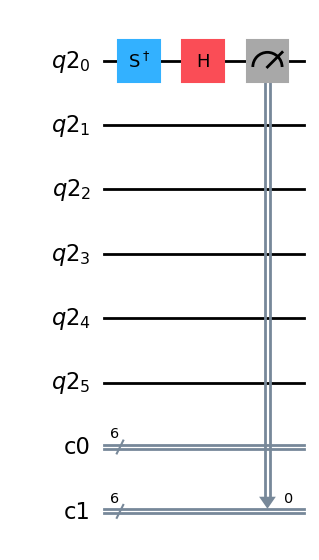

In [17]:
def eavesdropper_meas_circs(nq,QR_e,CR,CR_e):
    Eve_k_meas_circs = []
    Eve_k_meas_circs2 = []
    for k in range(0,nq):
        # Eavedropper measures qubit in X basis
        Eve_X = QuantumCircuit(QR_e,CR,CR_e)
        Eve_X.h(QR_e[k])
        Eve_X.measure(QR_e[k],CR_e[k])
        
        # Eve measures qubit in X basis
        Eve_X2 = QuantumCircuit(QR_e,CR,CR_e)
        Eve_X2.x(QR_e[k])
        Eve_X2.measure(QR_e[k],CR_e[k])
        
        # Eve measures qubit in Y basis
        Eve_Y = QuantumCircuit(QR_e,CR,CR_e)
        Eve_Y.sdg(QR_e[k])
        Eve_Y.h(QR_e[k])
        Eve_Y.measure(QR_e[k],CR_e[k])

        # Eve measures qubit in Y basis
        Eve_Y2 = QuantumCircuit(QR_e,CR,CR_e)
        Eve_Y2.y(QR_e[k])
        Eve_Y2.measure(QR_e[k],CR_e[k])
        Eve_k_meas_circs.append([Eve_X,Eve_Y])
        Eve_k_meas_circs2.append([Eve_X2,Eve_Y2])
    return Eve_k_meas_circs,Eve_k_meas_circs2
Eve_k_meas_circs,Eve_k_meas_circs2 = eavesdropper_meas_circs(nq,QR_e,CR,CR_e)
Eve_k_meas_circs[0][1].draw('mpl')

In [18]:
def circs_with_eavesdropper(nq,N,Eve_basis_choices,basis_choices,
                            Psi,Eve_k_meas_circs,Eve_k_meas_circs2,
                            Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2):
    circuits_Eve = [] 
    circuits_Eve2 = [] 
    #basis_choices[[],[]...[]]
    
    for k in range(N):
        if basis_choices[0][k] == 'X':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][0]
                circ2 = Psi & Eve_k_meas_circs2[0][0] & Legitimate_parties_meas_circs2[0][0]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][0]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][0]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
        elif basis_choices[0][k] == 'Y':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][1]
                circ2 = Psi & Eve_k_meas_circs2[0][0]& Legitimate_parties_meas_circs2[0][1]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][1]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][1]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
        elif basis_choices[0][k] == 'V':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][2]
                circ2 = Psi & Eve_k_meas_circs2[0][0] & Legitimate_parties_meas_circs2[0][2]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][2]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][2]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
    
        elif basis_choices[0][k] == 'R':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][3]
                circ2 = Psi & Eve_k_meas_circs2[0][0] & Legitimate_parties_meas_circs2[0][3]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][3]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][3]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
    for j in range(1,nq):
        for k in range(N):  
            circs = circuits_Eve[k]
            circs2 = circuits_Eve2[k]
            if basis_choices[j][k] == 'X':
                if Eve_basis_choices[k] == 'X':
                    circs = circs & Eve_k_meas_circs[j][0] & Legitimate_parties_meas_circs[j][0]
                    circs2 = circs2 & Eve_k_meas_circs2[j][0] & Legitimate_parties_meas_circs2[j][0]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
                elif Eve_basis_choices[k] == 'Y':
                    circs = circs & Eve_k_meas_circs[j][1] & Legitimate_parties_meas_circs[j][0]
                    circs2 = circs2 & Eve_k_meas_circs2[j][1] & Legitimate_parties_meas_circs2[j][0]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
            elif basis_choices[j][k] == 'Y':
                if Eve_basis_choices[k] == 'X':
                    circs = circs & Eve_k_meas_circs[j][0] & Legitimate_parties_meas_circs[j][1]
                    circs2 = circs2 &Eve_k_meas_circs2[j][0] & Legitimate_parties_meas_circs2[j][1]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
                elif Eve_basis_choices[k] == 'Y':
                    circs = circs & Eve_k_meas_circs[j][1] & Legitimate_parties_meas_circs[j][1]
                    circs2 = circs2 & Eve_k_meas_circs2[j][1] & Legitimate_parties_meas_circs2[j][1]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
    return circuits_Eve,circuits_Eve2
    
circuits_Eve,circuits_Eve2 = circs_with_eavesdropper(nq,N,Eve_basis_choices,basis_choices,
                            Psi,Eve_k_meas_circs,Eve_k_meas_circs2,
                            Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2)
print(len(circuits_Eve))
print(len(circuits_Eve2))


2000
2000


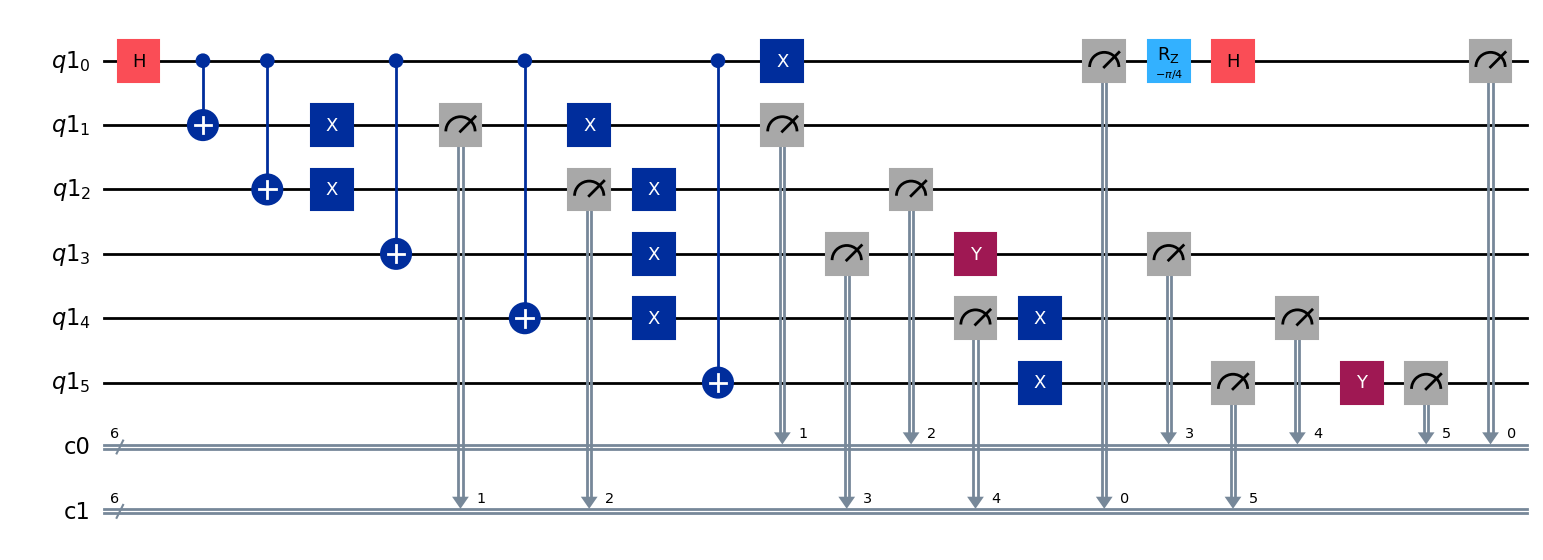

In [19]:
circuits_Eve2[50].draw('mpl')

In [20]:
def simulations(N,backend,circuits_Eve,circuits_Eve2):
    Result_Eve = []
    Result_Eve2 = []
    layout_list = [1]
    
    pmv = generate_preset_pass_manager(
        optimization_level = 1, 
        backend=backend, 
        seed_transpiler = 1234,
        # initial_layout = list(layout_list[j])
    )
    for k in range(N):
        qc = circuits_Eve[k]
        qc2 = circuits_Eve2[k]
        result = backend.run(qc, shots = 1).result() 
        result2 = backend.run(qc2, shots = 1).result()
    
        res = result.get_counts()
        res2 = result2.get_counts()
    
        Result_Eve.append(res)
        Result_Eve2.append(res2)
    return Result_Eve,Result_Eve2
Result_Eve,Result_Eve2= simulations(N,backend,circuits_Eve,circuits_Eve2)

In [21]:
print(Result_Eve)
print(Result_Eve2)

[{'011001 111000': 1}, {'100011 001010': 1}, {'110000 000111': 1}, {'101010 100111': 1}, {'111100 110000': 1}, {'110011 110011': 1}, {'111111 101011': 1}, {'101111 001111': 1}, {'110011 100000': 1}, {'010100 000111': 1}, {'001100 011011': 1}, {'001000 000111': 1}, {'001001 100000': 1}, {'000100 100110': 1}, {'010001 011010': 1}, {'000011 100110': 1}, {'100101 100010': 1}, {'101111 001101': 1}, {'110010 000101': 1}, {'001111 111000': 1}, {'110010 010111': 1}, {'100110 101100': 1}, {'011101 000110': 1}, {'000010 101001': 1}, {'010111 000100': 1}, {'110011 100110': 1}, {'011101 110110': 1}, {'110010 111111': 1}, {'100011 101010': 1}, {'100011 011100': 1}, {'001010 001111': 1}, {'101101 010010': 1}, {'110000 000101': 1}, {'101111 101000': 1}, {'001001 110000': 1}, {'100100 011101': 1}, {'000001 011010': 1}, {'001111 111100': 1}, {'111110 100111': 1}, {'000101 101100': 1}, {'000110 001111': 1}, {'111101 101111': 1}, {'100010 110111': 1}, {'011110 111110': 1}, {'001000 101011': 1}, {'101010 

In [22]:
def Legitimate_parties_secret_key_with_Eve(nq,N,Result_Eve):
    keyss_Legitimate_parties = np.array([[0]*N]*nq)
    for k in range(N):
        key = list(Result_Eve[k].keys())
        for j in range(nq):
            if key[0][nq+j+1] == '1':
                keyss_Legitimate_parties[j,k] = '1'
            elif key[0][nq+j+1] == '0':
                keyss_Legitimate_parties[j,k] = '0'
    
    Res = []
    L = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'X':
            l = ['X']
            for j in range(1,nq):
                l.append(basis_choices[j][k])
            L.append(l)
            k_list.append(k)
        elif basis_choices[0][k] == 'Y':
            l = ['Y']
            for j in range(1,nq):
                l.append(basis_choices[j][k])            
            L.append(l)
            k_list.append(k)

    Y_counter = []#This contains the number of Y basis in each set of bases in L
    for k in range(len(L)):
        compt = 0
        for j in range(len(L[0])):
            if L[k][j] == 'Y':
                compt += 1
        Y_counter.append(compt)
    
    Keys_Legitimate_parties = [] #this contains the set of key bit of each user
    for k in range(nq):
        q = keyss_Legitimate_parties[k]
        A = []
        for j in range(len(Y_counter)):
            if Y_counter[j]%2 == 0:# because when the is an odd number of Y basis selected the user
                                    # are most likely to get the same output results. 
                A.append(str(q[k_list[j]]))  
        Keys_Legitimate_parties.append(A)
    generated_keys_Legitimate_parties = []
    for k in range(len(Keys_Legitimate_parties)):
        x = ''
        for j in Keys_Legitimate_parties[k]:
            x += j
        generated_keys_Legitimate_parties.append(x)

    
    return generated_keys_Legitimate_parties
generated_keys_Legitimate_parties = Legitimate_parties_secret_key_with_Eve(nq,N,Result_Eve2)
generated_keys_Legitimate_parties

['10110011010100100011001010111111000001111100011010111000001101010111101011101010010101011000010001000111000100011001011001011010110100010001111101100000111101111000101000010011000010101101011010001001000011101011011010110111101010111000100100010001000000011110100110101011111011111011001011001110010010101110010111011101110100000110010100001001000001010111011101111100110010000110000110101110001100100100000111100100001011001111011010100110101001001010001001110011',
 '10110011010100100011001010111111000001111100011010111000001101010111101011101010010101011000010001000111000100011001011001011010110100010001111101100000111101111000101000010011000010101101011010001001000011101011011010110111101010111000100100010001000000011110100110101011111011111011001011001110010010101110010111011101110100000110010100001001000001010111011101111100110010000110000110101110001100100100000111100100001011001111011010100110101001001010001001110011',
 '101100110101001000110010101111110000011111000110101110000011

In [23]:
Keylength = [len(generated_keys_Legitimate_parties[k]) 
             for k in range(len(generated_keys_Legitimate_parties))]
Keylength

[464, 464, 464, 464, 464, 464]

In [24]:
#To compute the bit error rate I compare the bit of the first legitimate user
# to those of the remaining. It works as follows: I take the kth bit of the first user, compare
#compare with the kth bit of others, the mismatching is incremented by 1 when at least one bit
#differs.
def Legitimate_parties_QBER_with_eve(Keylength,keys):
    Numb_mismatching_bits = 0 
    x = keys[0]
    if Keylength[0] == 0:
        print('Unsucessful')
    else:
        for j in range(Keylength[0]):
            for k in range(1,nq):
                if x[j] != keys[k][j]:
                    Numb_mismatching_bits +=1
                    break
        QBER = Numb_mismatching_bits/Keylength[0]*100
    return QBER
        
QBER_with_Eve = Legitimate_parties_QBER_with_eve(Keylength,generated_keys_Legitimate_parties)
print('QBER = ', QBER_with_Eve,'%')

QBER =  0.0 %


In [25]:
def Eve_extracted_keys(nq,N,Result_Eve):
    keyss_Eve = np.array([[0]*N]*nq)
    for k in range(N):
        key = list(Result_Eve[k].keys())
        for j in range(nq):
            if key[0][j] == '1':
                keyss_Eve[j,k] = '1'
            elif key[0][j] == '0':
                keyss_Eve[j,k] = '0'

    
    L = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'X':
            l = ['X']
            for j in range(1,nq):
                l.append(basis_choices[j][k])
            L.append(l)
            k_list.append(k)
        elif basis_choices[0][k] == 'Y':
            l = ['Y']
            for j in range(1,nq):
                l.append(basis_choices[j][k])            
            L.append(l)
            k_list.append(k)

    Y_counter = []#This contains the number of Y basis in each set of bases in L
    for k in range(len(L)):
        compt = 0
        for j in range(len(L[0])):
            if L[k][j] == 'Y':
                compt += 1
        Y_counter.append(compt)
    
    #Here I am extracting the bit where the measurement basis correspond to the 
    Keys_Eve = [] #this contains the set of key bit of each user
    for k in range(nq):
        q = keyss_Eve[k]
        A = []
        for j in range(len(Y_counter)):
            if Y_counter[j]%2 == 0:# because when the is an odd number of Y basis selected the user
                                    # are most likely to get the same output results. 
                A.append(str(q[k_list[j]]))  
        Keys_Eve.append(A)
    generated_keys_Eve = []
    for k in range(len(Keys_Eve)):
        x = ''
        for j in Keys_Eve[k]:
            x += j
        generated_keys_Eve.append(x)

    return generated_keys_Eve
generated_keys_Eve = Eve_extracted_keys(nq,N,Result_Eve)
print(generated_keys_Eve)

['11100011110100100111111101101100011010000000110001100110110010111111001101000110101111111010010000100100101110101101110111000100110100011100011101010111011010000110010111000000010111101111111110111110111011011100011110100110111000100000100010101000000000001001011011001011011000001000010101111010000001011110111111001110001111000011111110101001101000111100100001111010110011001011100001101101010001111010010111000001111011000110010111110010100101110100000100101100', '01000001110100011111111110101100001011101110110010110111111100000111111000101101010101111010000001100010000101010001000000110011010100101100001101001010011001110111000001010010011110010110101100101100111010101100001011010100111010111111101011100111011101011010110011101101101011001000110000100110000000011100010111101100100100000100110010010001001000001101000100010010010100011000000011101011101010001001101011101000011100010100101001001101010000111110011010101000', '00111100000101001010010101010001111101000111101110011110100110

In [26]:
def Percentage_info_learnt_by_Eve(generated_keys_Eve):
    Percentage_Eve_mismatching_bits = [] 
    
    for k in range(len(generated_keys_Eve)):
        Numb_mismatching_bits =0
        x = generated_keys_Eve[k]
        Eve_Keylength = len(generated_keys_Eve[k])
        if Eve_Keylength == 0:
            Numb_Eve_mismatching_bits.append('Unsucessful')
        else:
            for j in range(Eve_Keylength):
                if x[j] != generated_keys[k][j]:
                    Numb_mismatching_bits +=1
                    # break
            QBER = Numb_mismatching_bits/Keylength[0]*100
            Percentage_Eve_mismatching_bits.append(QBER)
    return Percentage_Eve_mismatching_bits

Percentage_Eve_mismatching_bits  = Percentage_info_learnt_by_Eve(generated_keys_Eve)
print('Percentage of Eve mismatching bits = ', Percentage_Eve_mismatching_bits)

Percentage of Eve mismatching bits =  [48.922413793103445, 55.172413793103445, 50.0, 51.077586206896555, 48.060344827586206, 46.33620689655172]


In [29]:
correlation2 = Corrrelation(basis_choices,Result_Eve2)
print('The Svetlichny correlation with eavesdropper interference is',np.round(correlation2[0],3),
      'compared to the theoretical values',np.round(correlation2[1],3))


The Svetlichny correlation with eavesdropper interference is -4.732 compared to the theoretical values 45.255


C:\Users\alain\AppData\Local\Temp\ipykernel_27376\509065364.py:108: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()
